# 🧠 5.3 BiLSTM Classification Model con Gated Pooling

Este notebook entrena clasificadores basados en **LSTM Bidireccionales (BiLSTM)** con **Gated Pooling** para la clasificación binaria sobre los embeddings generados por ProtFlash. A diferencia de MLP o CNN, el BiLSTM modela dependencias secuenciales a lo largo de la secuencia, mientras que el `GatedPooler` pondera dinámicamente la contribución de cada residuo antes de la capa recurrente.

---

## 📋 Descripción general

El modelo recibe tres entradas:
- `X`: embeddings por residuo, con forma `(B, L, 768)`.
- `G`: embedding global/contextual de la secuencia, con forma `(B, 768)`.
- `M`: máscara binaria, con forma `(B, L)`, usada para ignorar posiciones de padding.

La arquitectura `GatedBiLSTMClassifier`:
1. Calcula gates por residuo mediante `GatedPooler`, respetando la máscara `M`.
2. Modula los embeddings por residuo `X` mediante los gates aprendidos.
3. Procesa la secuencia modulada con una red `BiLSTM` bidireccional usando `pack_padded_sequence`.
4. Agrega las salidas del LSTM mediante *max pooling* y *average pooling*.
5. Concatena la representación agregada del LSTM con el embedding global `G`.
6. Procesa la representación combinada con capas `Linear`, `BatchNorm1d`, `GELU` y `Dropout`, y finaliza con una capa lineal de logits.

---

## 🛠️ Funcionalidades principales

1. **Arquitectura del modelo**
   - `GatedPooler` para ponderar residuos antes del modelado secuencial.
   - BiLSTM bidireccional con manejo de longitudes variables mediante `pack_padded_sequence`.
   - Agregación de las salidas recurrentes mediante *max pooling* y *average pooling*.
   - Cabeza MLP con `Linear`, `BatchNorm1d`, `GELU` y `Dropout`.

2. **Entrenamiento y optimización**
   - Optimizador `AdamW` con *weight decay*.
   - Función de pérdida `BCEWithLogitsLoss` con `pos_weight` para manejar el desbalance de clases.
   - *Gradient clipping* para estabilizar el entrenamiento recurrente.
   - `ReduceLROnPlateau` y *early stopping* basado en la pérdida de validación.

3. **Búsqueda de hiperparámetros**
   - Evaluación de tres configuraciones: `Gated_BiLSTM_Small`, `Gated_BiLSTM_Medium` y `Gated_BiLSTM_Large`.
   - Variación de `hidden_size`, número de capas LSTM, capas MLP, *dropout* y tasa de aprendizaje.

4. **Monitoreo y registro**
   - Registro por época de pérdida de entrenamiento/validación, accuracy, F1, MCC y ROC-AUC.
   - Guardado automático del mejor modelo según la menor pérdida de validación.
   - Exportación de checkpoints, métricas y curvas de entrenamiento.

## 📦 Importación de librerías y entorno

In [1]:
import os
import json
import random
import time
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    matthews_corrcoef, confusion_matrix
)
import matplotlib.pyplot as plt

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.10.0+cu128
cuda available: True


## ⚙️ Configuración de rutas e hiperparámetros BiLSTM

In [2]:
# ========== PATHS ==========
DATA_DIR = Path("/kaggle/input/datasets/user/new-final-dataset")
OUT_DIR = Path("/kaggle/working/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PT  = DATA_DIR / "train_dataset.pt"
VAL_PT    = DATA_DIR / "val_dataset.pt"

# ========== HYPERPARAMETERS ==========
SEED        = 31
BATCH_SIZE  = 32
MAX_EPOCHS  = 100
PATIENCE    = 12
MIN_DELTA   = 1e-4
INPUT_DIM   = 768
L_MAX       = 100

# ========== ARCHITECTURES ==========
ARCHITECTURES = [
    {
        "name": "Gated_BiLSTM_Small",
        "hidden_size": 128,
        "num_layers": 1,
        "mlp_hidden": [128],
        "dropout": 0.3,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "Gated_BiLSTM_Medium",
        "hidden_size": 256,
        "num_layers": 2,
        "mlp_hidden": [128],
        "dropout": 0.4,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "Gated_BiLSTM_Large",
        "hidden_size": 512,
        "num_layers": 2,
        "mlp_hidden": [256, 128],
        "dropout": 0.5,
        "lr": 5e-4,
        "weight_decay": 1e-4,
    },
]

print(f"Architectures to compare: {len(ARCHITECTURES)}")
for cfg in ARCHITECTURES:
    print(f"  - {cfg['name']}: hidden={cfg['hidden_size']}, layers={cfg['num_layers']}, dropout={cfg['dropout']}")

Architectures to compare: 3
  - Gated_BiLSTM_Small: hidden=128, layers=1, dropout=0.3
  - Gated_BiLSTM_Medium: hidden=256, layers=2, dropout=0.4
  - Gated_BiLSTM_Large: hidden=512, layers=2, dropout=0.5


## 🖥️ Semilla para reproducibilidad y detección de dispositivo

In [3]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


## 📂 Definición de la clase `AMPDataset`

In [4]:
class AMPDataset(Dataset):
    """
    Dataset for training the AMP classifier with Gated Pooling.

    Returns:
        X:     torch.FloatTensor (L_max, 768)    — ProtFlash embeddings
        G:     torch.FloatTensor (768,)          — Global/CLS context embedding
        M:     torch.FloatTensor (L_max,)        — binary mask
        y:     torch.FloatTensor (1,)            — label
    """
    def __init__(self, X, G, M, labels):
        self.X = torch.from_numpy(X).float()          # (N, 100, 768)
        self.G = torch.from_numpy(G).float()          # (N, 768)
        self.M = torch.from_numpy(M).float()          # (N, 100)
        self.y = torch.from_numpy(labels).float().unsqueeze(1)  # (N, 1)

        assert len(self.X) == len(self.G) == len(self.M) == len(self.y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "X": self.X[idx],           # (100, 768)
            "G": self.G[idx],           # (768,)
            "M": self.M[idx],           # (100,)
            "y": self.y[idx]            # (1,)
        }

## 💾 Función de carga de datasets pre-serializados

In [5]:
def load_pt_dataset(pt_path):
    pt_path = Path(pt_path)
    if not pt_path.exists(): raise FileNotFoundError
    return torch.load(pt_path, map_location="cpu", weights_only=False)

## 📥 Carga de splits de entrenamiento y validación

In [6]:
print("Loading datasets:")
train_ds = load_pt_dataset(TRAIN_PT)
val_ds   = load_pt_dataset(VAL_PT)

print(f"\n🔍 Test __len__:")
print(f"   train_ds: {len(train_ds)} muestras")
print(f"   val_ds  : {len(val_ds)} muestras")

print(f"\n🔍 Test __getitem__[0]:")
sample = train_ds[0]
keys = ['X', 'G', 'M', 'y']

for k, v in zip(keys, sample):
    if isinstance(v, torch.Tensor):
        print(f"   {k}: {tuple(v.shape)} {v.dtype}")
    else:
        print(f"   {k}: {type(v).__name__} = '{str(v)[:50]}'")

Loading datasets:

🔍 Test __len__:
   train_ds: 13766 muestras
   val_ds  : 4128 muestras

🔍 Test __getitem__[0]:
   X: str = 'X'
   G: str = 'G'
   M: str = 'M'
   y: str = 'y'


## 🤝 Función de colación (`collate_fn`)

In [7]:
def collate_fn(batch):
    if isinstance(batch[0], dict):
        embeddings = torch.stack([item['X'] for item in batch], dim=0)
        globals_emb = torch.stack([item['G'] for item in batch], dim=0) 
        masks       = torch.stack([item['M'] for item in batch], dim=0)
        labels      = torch.stack([item['y'] for item in batch], dim=0)
    else:
        raise TypeError(f"Batch fallido")
    return embeddings, globals_emb, masks, labels

## 🚚 Creación de DataLoaders

In [8]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"\n✅ Batches: train={len(train_loader)}, val={len(val_loader)}")

X_b, G_b, M_b, y_b = next(iter(train_loader))
print(f"   ✅ X_b: {tuple(X_b.shape)} | G_b: {tuple(G_b.shape)}")


✅ Batches: train=431, val=129
   ✅ X_b: (32, 100, 768) | G_b: (32, 768)


## 🧩 Capa `GatedPooler`

In [9]:
class GatedPooler(nn.Module):
    """
    Gated pooling diferenciable.

    Input:
        - X: (B, L, D) embeddings por residuo
        - M: (B, L) máscara binaria

    Output:
        - E: (B, D) embedding agregado por secuencia
    """

    def __init__(self, input_dim: int):
        super().__init__()

        # Gate aprendido desde el embedding de cada residuo
        self.gating_mlp = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

        # Proyección opcional
        self.proj = nn.Linear(input_dim, input_dim)

    def forward(self, X: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        # X: (B, L, D)
        # M: (B, L)

        gates = self.gating_mlp(X) * M.unsqueeze(-1)   # (B, L, 1)

        weighted = gates * self.proj(X)

        # Media ponderada
        return weighted.sum(dim=1) / (gates.sum(dim=1) + 1e-8)

    def get_gates(self, X: torch.Tensor, M: torch.Tensor):
        gates = self.gating_mlp(X)
        gates = gates * M.unsqueeze(-1)
        return gates

## 🏗️ Arquitectura `GatedBiLSTMClassifier` y Verificación

In [10]:
class GatedBiLSTMClassifier(nn.Module):
    """
    BiLSTM classifier con Gated Pooling aprendido.
    """

    def __init__(
        self,
        input_dim: int,
        hidden_size: int,
        num_layers: int,
        mlp_hidden: List[int],
        dropout: float = 0.3,
    ):
        super().__init__()

        self.pooler = GatedPooler(input_dim=input_dim)

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        lstm_out_dim = hidden_size * 4
        clf_in_dim = lstm_out_dim + input_dim

        layers = []

        for h_dim in mlp_hidden:
            layers.append(nn.Linear(clf_in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            clf_in_dim = h_dim

        self.mlp = nn.Sequential(*layers)
        self.classifier = nn.Linear(clf_in_dim, 1)

    def forward(
        self,
        X: torch.Tensor,
        G: torch.Tensor,
        M: torch.Tensor,
    ):

        # ----------------------------
        # 1) Gating por residuo
        # ----------------------------
        gates = self.pooler.get_gates(X, M)          # (B,L,1)

        X = X * gates                                # (B,L,D)

        # ----------------------------
        # 2) BiLSTM
        # ----------------------------
        lengths = M.sum(dim=1).clamp(min=1).cpu()

        packed = pack_padded_sequence(
            X,
            lengths,
            batch_first=True,
            enforce_sorted=False,
        )

        packed_out, _ = self.lstm(packed)

        lstm_out, _ = pad_packed_sequence(
            packed_out,
            batch_first=True,
            total_length=X.size(1),
        )

        # ----------------------------
        # 3) Pooling
        # ----------------------------
        mask = M.unsqueeze(-1).bool()

        max_pool = lstm_out.masked_fill(~mask, -1e9).max(dim=1)[0]

        avg_pool = (
            lstm_out.masked_fill(~mask, 0.0).sum(dim=1)
            / M.sum(dim=1, keepdim=True).clamp(min=1e-8)
        )

        lstm_features = torch.cat(
            [max_pool, avg_pool],
            dim=1,
        )

        # ----------------------------
        # 4) Clasificador
        # ----------------------------
        combined = torch.cat(
            [
                lstm_features,
                G,
            ],
            dim=1,
        )

        x = self.mlp(combined)

        return self.classifier(x)

    def get_gates(
        self,
        X: torch.Tensor,
        M: torch.Tensor,
    ):
        return self.pooler.get_gates(X, M).squeeze(-1)

def build_lstm_model(config: Dict, input_dim: int) -> nn.Module:
    return GatedBiLSTMClassifier(
        input_dim, 
        config["hidden_size"], 
        config["num_layers"], 
        config["mlp_hidden"], 
        config["dropout"]
    )

# ========== SANITY CHECK ==========
_test_model = build_lstm_model(ARCHITECTURES[0], INPUT_DIM)

_test_X = torch.randn(2, L_MAX, INPUT_DIM)
_test_G = torch.randn(2, INPUT_DIM)

_test_M = torch.ones(2, L_MAX)
_test_M[0, 50:] = 0

with torch.no_grad():
    _test_out = _test_model(_test_X, _test_G, _test_M)
    _test_gates = _test_model.get_gates(_test_X, _test_M)

_n = sum(p.numel() for p in _test_model.parameters())

print(
    f"Sanity check ({ARCHITECTURES[0]['name']}): "
    f"params={_n:,}, "
    f"output shape={_test_out.shape}, "
    f"gates shape={_test_gates.shape}"
)

del _test_model, _test_X, _test_G, _test_M, _test_out, _test_gates

Sanity check (Gated_BiLSTM_Small): params=1,773,058, output shape=torch.Size([2, 1]), gates shape=torch.Size([2, 100])


## 📐 Helper: `sigmoid_np`

In [11]:
def sigmoid_np(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

## 🔮 Inferencia: `predict_proba`

In [12]:
@torch.no_grad()
def predict_proba(model, loader, device):

    model.eval()

    logits_list = []
    y_list = []

    for Xb, Gb, Mb, yb in loader:

        Xb = Xb.to(device)
        Gb = Gb.to(device)
        Mb = Mb.to(device)

        logits = model(Xb, Gb, Mb)

        logits_list.append(logits.cpu().numpy().reshape(-1))
        y_list.append(yb.cpu().numpy().reshape(-1))

    proba = torch.sigmoid(torch.tensor(np.concatenate(logits_list))).numpy()
    y = np.concatenate(y_list)

    return proba, y

## 📏 Cálculo de Métricas de Clasificación

In [13]:
def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = y_true.astype(int)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)) if len(np.unique(y_true)) > 1 else 0.0,
        "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
        "pr_auc": float(average_precision_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
    }

In [14]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
    def forward(self, inputs, targets):
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce)
        return (self.alpha * (1 - pt)**self.gamma * bce).mean()

## 🔄 Loops de Entrenamiento

In [15]:
def train_model(config, input_dim, train_loader, val_loader, device,
                max_epochs=MAX_EPOCHS, patience=PATIENCE):

    seed_everything(SEED)

    model = build_lstm_model(config, input_dim).to(device)

    criterion = FocalLoss(alpha=0.75, gamma=2.0).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5
    )

    history = {"epoch": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_mcc": [], "val_roc_auc": []}

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    no_improve = 0

    for epoch in range(1, max_epochs + 1):

        # ================= TRAIN =================
        model.train()

        train_loss = 0.0
        n = 0

        for Xb, Gb, Mb, yb in train_loader:

            Xb = Xb.to(device)
            Gb = Gb.to(device)
            Mb = Mb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            logits = model(Xb, Gb, Mb)

            loss = criterion(logits, yb)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            train_loss += loss.item() * Xb.size(0)
            n += Xb.size(0)

        train_loss /= n

        # ================= VALIDATION =================
        model.eval()

        val_loss = 0.0
        n = 0

        with torch.no_grad():

            for Xb, Gb, Mb, yb in val_loader:

                Xb = Xb.to(device)
                Gb = Gb.to(device)
                Mb = Mb.to(device)
                yb = yb.to(device)

                logits = model(Xb, Gb, Mb)

                loss = criterion(logits, yb)

                val_loss += loss.item() * Xb.size(0)
                n += Xb.size(0)

        val_loss /= n

        scheduler.step(val_loss)

        train_p, train_y = predict_proba(model, train_loader, device)
        val_p, val_y = predict_proba(model, val_loader, device)
        v_met = compute_metrics(val_y, val_p)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(compute_metrics(train_y, train_p)["accuracy"]); 
        history["val_acc"].append(v_met["accuracy"])
        history["val_mcc"].append(v_met["mcc"])
        history["val_roc_auc"].append(v_met["roc_auc"])

        if val_loss < best_val_loss - MIN_DELTA:

            best_val_loss = val_loss
            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

            best_epoch = epoch
            no_improve = 0

        else:
            no_improve += 1

        print(f"E{epoch:02d} | TL: {train_loss:.4f} | VL: {val_loss:.4f} | Val MCC: {v_met['mcc']:.4f} | B_ep: {best_epoch}")

        if no_improve >= patience:
            break

    model.load_state_dict(best_state)

    return {
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
    }

## 🔬 Ejecución Secuencial de Arquitecturas

In [16]:
all_results = []
for idx, config in enumerate(ARCHITECTURES):
    print(f"\n--- Entrenando {config['name']} ---")
    res = train_model(config, INPUT_DIM, train_loader, val_loader, DEVICE)
    val_proba, val_y = predict_proba(res["model"], val_loader, DEVICE)
    v_metrics = compute_metrics(val_y, val_proba)
    n_params = sum(p.numel() for p in res["model"].parameters())

    ckpt_path = OUT_DIR / f"checkpoint_{config['name']}.pth"
    torch.save({
        "model_name": config["name"],
        "state_dict": res["model"].state_dict(),
        "config": config,
        "input_dim": INPUT_DIM
    }, ckpt_path)

    all_results.append({
        "name": config["name"],
        "n_params": n_params,
        "best_epoch": res["best_epoch"],
        "best_val_loss": res["best_val_loss"],
        "val_accuracy": v_metrics["accuracy"],
        "val_f1": v_metrics["f1"],
        "val_mcc": v_metrics["mcc"],
        "val_roc_auc": v_metrics["roc_auc"],
        "val_pr_auc": v_metrics["pr_auc"],
        "model": res["model"],
        "config": config,
        "history": res["history"],
        "training_time_sec": 0.0,
    })

    
    print(f"\n  ✅ {config['name']}: params={n_params:,} | "
          f"best_epoch={res['best_epoch']} | val_loss={res['best_val_loss']:.4f}")
    print(f"     val_acc={v_metrics['accuracy']:.4f} | val_f1={v_metrics['f1']:.4f} | "
          f"val_mcc={v_metrics['mcc']:.4f} | val_roc_auc={v_metrics.get('roc_auc', 0.0):.4f}")
    print(f"     Saved: {ckpt_path}")

print("\n" + "=" * 90)
print("ALL EXPERIMENTS COMPLETE")
print("=" * 90)


--- Entrenando Gated_BiLSTM_Small ---
E01 | TL: 0.0606 | VL: 0.0553 | Val MCC: 0.7557 | B_ep: 1
E02 | TL: 0.0516 | VL: 0.0510 | Val MCC: 0.7825 | B_ep: 2
E03 | TL: 0.0481 | VL: 0.0549 | Val MCC: 0.7881 | B_ep: 2
E04 | TL: 0.0467 | VL: 0.0493 | Val MCC: 0.8000 | B_ep: 4
E05 | TL: 0.0436 | VL: 0.0477 | Val MCC: 0.8011 | B_ep: 5
E06 | TL: 0.0406 | VL: 0.0495 | Val MCC: 0.8022 | B_ep: 5
E07 | TL: 0.0391 | VL: 0.0512 | Val MCC: 0.8050 | B_ep: 5
E08 | TL: 0.0378 | VL: 0.0492 | Val MCC: 0.8115 | B_ep: 5
E09 | TL: 0.0373 | VL: 0.0519 | Val MCC: 0.8071 | B_ep: 5
E10 | TL: 0.0345 | VL: 0.0474 | Val MCC: 0.8122 | B_ep: 10
E11 | TL: 0.0331 | VL: 0.0504 | Val MCC: 0.8157 | B_ep: 10
E12 | TL: 0.0331 | VL: 0.0484 | Val MCC: 0.8088 | B_ep: 10
E13 | TL: 0.0311 | VL: 0.0518 | Val MCC: 0.7993 | B_ep: 10
E14 | TL: 0.0294 | VL: 0.0571 | Val MCC: 0.7664 | B_ep: 10
E15 | TL: 0.0281 | VL: 0.0515 | Val MCC: 0.8131 | B_ep: 10
E16 | TL: 0.0275 | VL: 0.0661 | Val MCC: 0.8016 | B_ep: 10
E17 | TL: 0.0213 | VL: 0.0

## 📊 Tabla Resumen y Ranking de Modelos

In [17]:
summary_rows = []
for r in all_results:
    summary_rows.append({
        "Model": r["name"],
        "Params": r["n_params"],
        "Best Epoch": r["best_epoch"],
        "Val Loss": r["best_val_loss"],
        "Val Acc": r["val_accuracy"],
        "Val F1": r["val_f1"],
        "Val MCC": r["val_mcc"],
        "Val ROC-AUC": r["val_roc_auc"],
        "Val PR-AUC": r["val_pr_auc"],
        "Time (s)": round(r["training_time_sec"], 1),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Val MCC", ascending=False).reset_index(drop=True)

print("\n" + "=" * 100)
print("ARCHITECTURE COMPARISON (sorted by Val MCC)")
print("=" * 100)
print(summary_df.to_string())
print("=" * 100)

summary_df.to_csv(OUT_DIR / "lstm_architecture_comparison.csv", index=False)
print(f"\nSaved")

best_name = summary_df.iloc[0]["Model"]
best_result = next(r for r in all_results if r["name"] == best_name)
print(f"\n🏆 Best model: {best_name}")


ARCHITECTURE COMPARISON (sorted by Val MCC)
                 Model    Params  Best Epoch  Val Loss   Val Acc    Val F1   Val MCC  Val ROC-AUC  Val PR-AUC  Time (s)
0   Gated_BiLSTM_Small   1773058          10  0.047420  0.906008  0.896478  0.812235     0.961811    0.967287       0.0
1  Gated_BiLSTM_Medium   4597250           9  0.046776  0.903343  0.890113  0.810507     0.963248    0.967726       0.0
2   Gated_BiLSTM_Large  12994818           5  0.047667  0.898740  0.883565  0.803047     0.959386    0.964401       0.0

Saved

🏆 Best model: Gated_BiLSTM_Small


## 📈 Visualización: Curvas de Entrenamiento Individuales

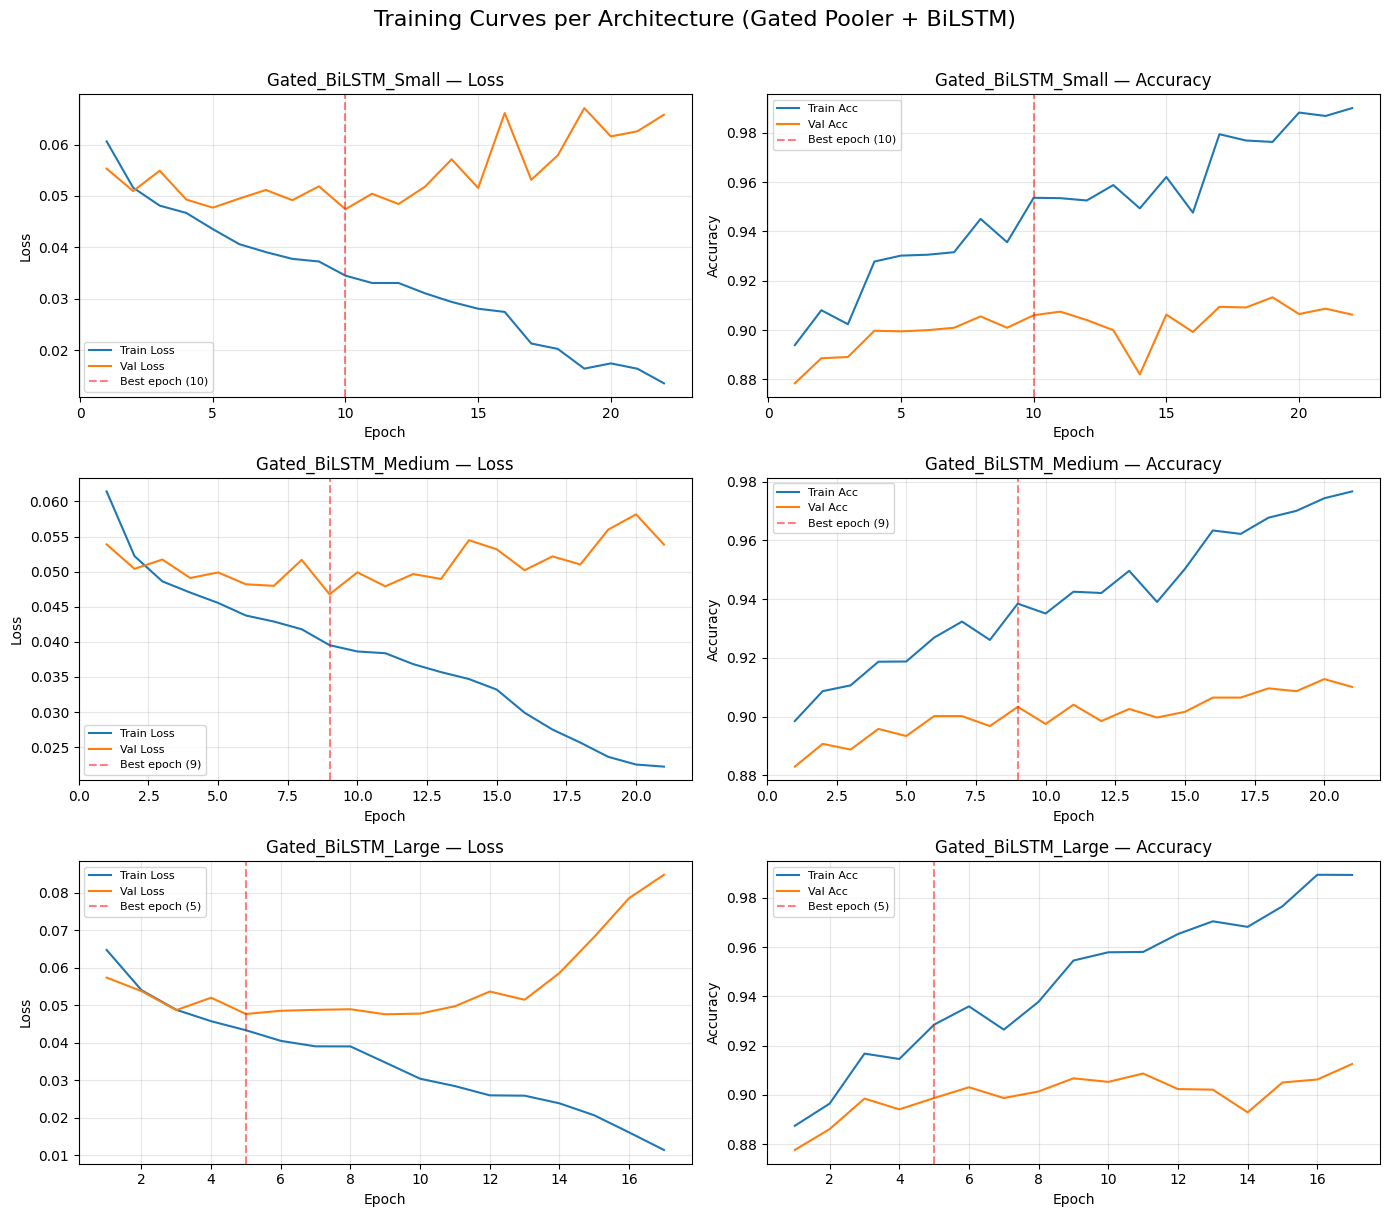

Saved: /kaggle/working/training_curves_individual.png


In [18]:
n_models = len(all_results)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 4 * n_models), squeeze=False)

for idx, r in enumerate(all_results):
    h = r["history"]
    epochs = h["epoch"]

    ax_loss = axes[idx, 0]
    ax_loss.plot(epochs, h["train_loss"], label="Train Loss", linewidth=1.5)
    ax_loss.plot(epochs, h["val_loss"], label="Val Loss", linewidth=1.5)
    ax_loss.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({r['best_epoch']})")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.set_title(f"{r['name']} — Loss")
    ax_loss.legend(fontsize=8)
    ax_loss.grid(True, alpha=0.3)

    ax_acc = axes[idx, 1]
    ax_acc.plot(epochs, h["train_acc"], label="Train Acc", linewidth=1.5)
    ax_acc.plot(epochs, h["val_acc"], label="Val Acc", linewidth=1.5)
    ax_acc.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({r['best_epoch']})")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_title(f"{r['name']} — Accuracy")
    ax_acc.legend(fontsize=8)
    ax_acc.grid(True, alpha=0.3)

fig.suptitle("Training Curves per Architecture (Gated Pooler + BiLSTM)", fontsize=16, y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves_individual.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'training_curves_individual.png'}")

## 📈 Visualización: Curvas comparativas conjuntas

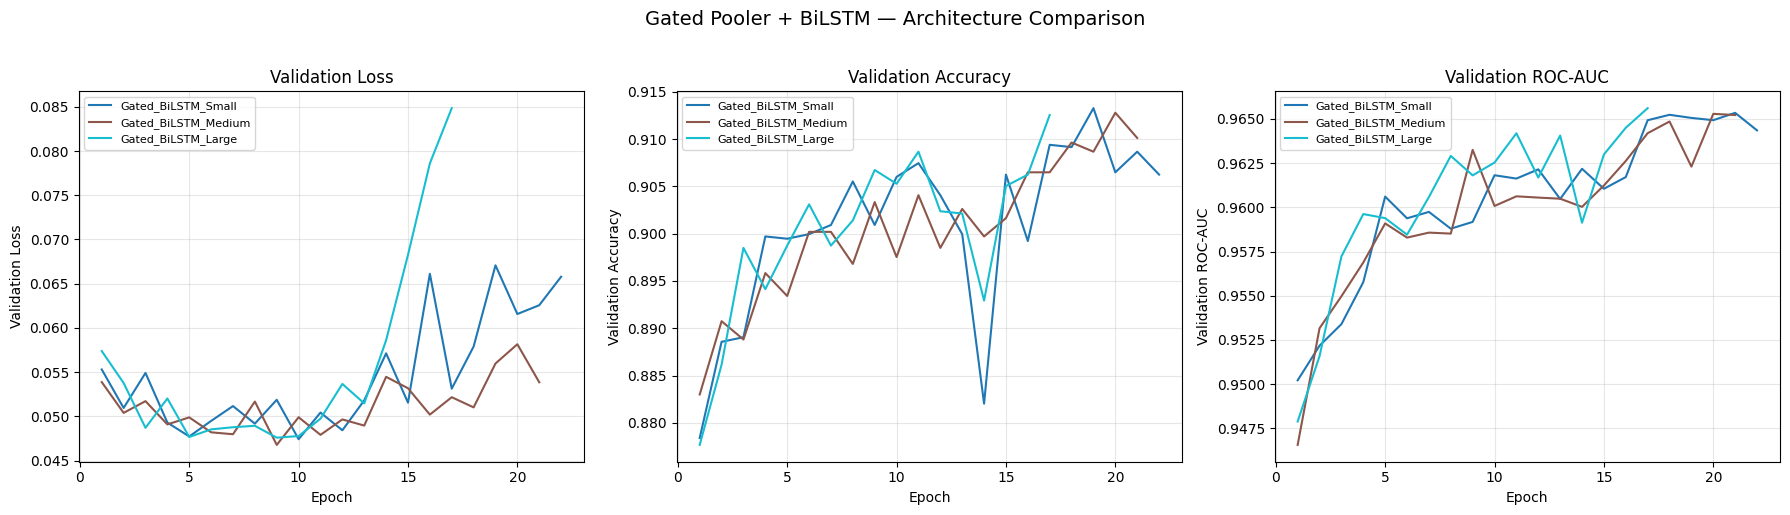

Saved: /kaggle/working/training_curves_comparison.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.tab10(np.linspace(0, 1, n_models))

for idx, r in enumerate(all_results):
    h = r["history"]
    axes[0].plot(h["epoch"], h["val_loss"], label=r["name"], color=colors[idx], linewidth=1.5)
    axes[1].plot(h["epoch"], h["val_acc"], label=r["name"], color=colors[idx], linewidth=1.5)
    axes[2].plot(h["epoch"], h["val_roc_auc"], label=r["name"], color=colors[idx], linewidth=1.5)

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Validation Loss"); axes[0].set_title("Validation Loss")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation Accuracy"); axes[1].set_title("Validation Accuracy")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Validation ROC-AUC"); axes[2].set_title("Validation ROC-AUC")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

fig.suptitle("Gated Pooler + BiLSTM — Architecture Comparison", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'training_curves_comparison.png'}")

## 📊 Visualización: Gráfico de Barras Comparativo

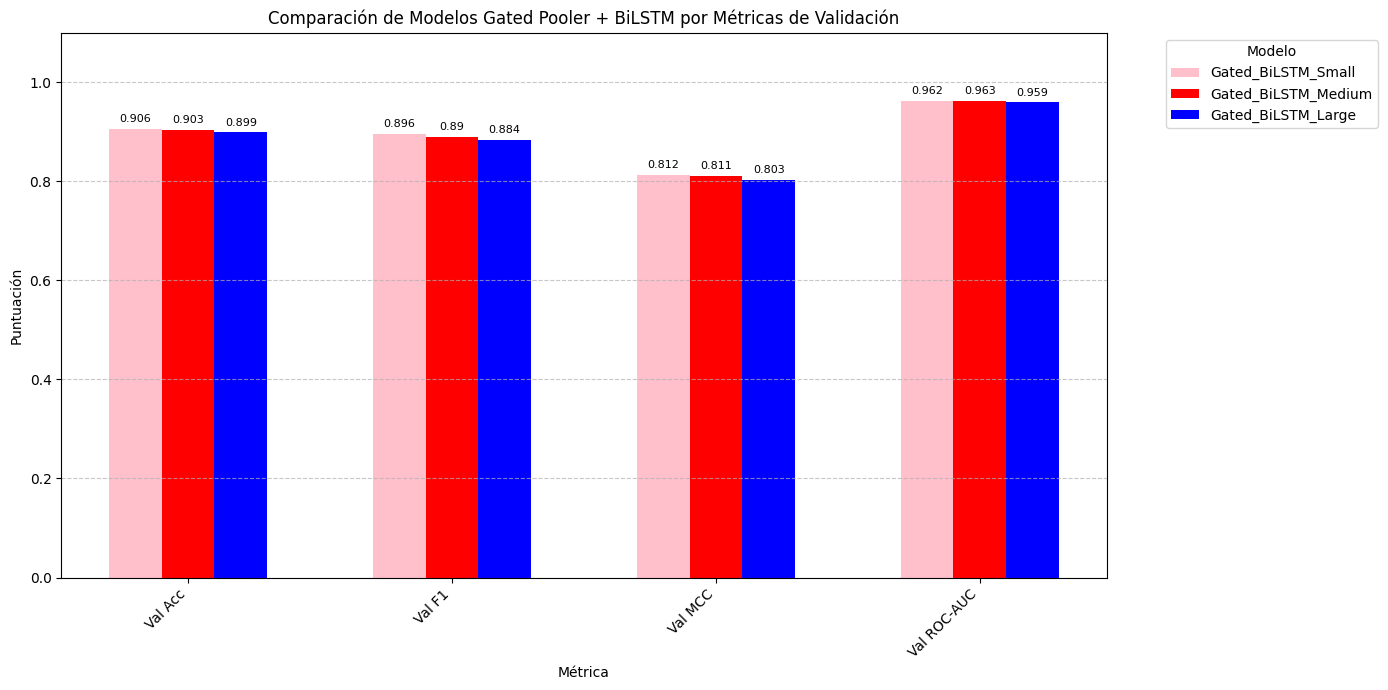

Saved: /kaggle/working/model_metrics_comparison_bar_chart.png


In [20]:
metric_cols = ["Val Acc", "Val F1", "Val MCC", "Val ROC-AUC"]
model_names = summary_df['Model'].tolist()

fig, ax = plt.subplots(figsize=(14, 7))
bar_width = 0.2
index = np.arange(len(metric_cols))
custom_colors = ['pink', 'red', 'blue', 'violet']

for i, model_name in enumerate(model_names):
    model_scores = summary_df[summary_df['Model'] == model_name][metric_cols].values.flatten()
    bars = ax.bar(index + i * bar_width, model_scores, bar_width, label=model_name, color=custom_colors[i % len(custom_colors)])
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 3),
                ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Métrica')
ax.set_ylabel('Puntuación')
ax.set_title('Comparación de Modelos Gated Pooler + BiLSTM por Métricas de Validación')
ax.set_xticks(index + bar_width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metric_cols, rotation=45, ha='right')
ax.set_ylim(0, 1.1)
ax.legend(title='Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plot_path = OUT_DIR / "model_metrics_comparison_bar_chart.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")

## 💾 Guardado del Mejor Modelo y Artefactos

In [21]:
best_model = best_result["model"]
best_config = best_result["config"]

val_proba_final, val_y_final = predict_proba(best_model, val_loader, DEVICE)
val_metrics_final = compute_metrics(val_y_final, val_proba_final)

final_ckpt_path = OUT_DIR / "best_model_final.pth"
final_checkpoint = {
    "model_name": best_config["name"],
    "state_dict": best_model.state_dict(),
    "config": best_config,
    "input_dim": INPUT_DIM,
    "n_params": best_result["n_params"],
    "best_epoch": best_result["best_epoch"],
    "best_val_loss": best_result["best_val_loss"],
    "training_time_sec": best_result["training_time_sec"],
    "val_metrics": val_metrics_final,
    "history": best_result["history"],
    "hyperparameters": {
        "seed": SEED,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,
        "lr": best_config["lr"],
        "weight_decay": best_config["weight_decay"],
    },
}
torch.save(final_checkpoint, final_ckpt_path)

history_df = pd.DataFrame(best_result["history"])
history_path = OUT_DIR / "best_model_training_log.csv"
history_df.to_csv(history_path, index=False)

metrics_path = OUT_DIR / "best_model_val_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(val_metrics_final, f, indent=2)

print(f"\n🏆 Best model: {best_config['name']}")
print(f"   Parameters: {best_result['n_params']:,}")
print(f"   Best epoch: {best_result['best_epoch']}")
print(f"   Val loss:   {best_result['best_val_loss']:.6f}")
print(f"\nSaved:")
print(f"  Checkpoint:    {final_ckpt_path}")
print(f"  Training log:  {history_path}")
print(f"  Val metrics:   {metrics_path}")


🏆 Best model: Gated_BiLSTM_Small
   Parameters: 1,773,058
   Best epoch: 10
   Val loss:   0.047420

Saved:
  Checkpoint:    /kaggle/working/best_model_final.pth
  Training log:  /kaggle/working/best_model_training_log.csv
  Val metrics:   /kaggle/working/best_model_val_metrics.json


## 🏆 Conclusión: el mejor modelo

Tras completar el proceso de experimentación, se concluye que la configuración **Gated_BiLSTM_Small** ofrece el mejor rendimiento entre las arquitecturas BiLSTM con Gated Pooling evaluadas, según la métrica de validación **MCC**.

### Resultados destacados

| Métrica       | Valor  |
|---------------|--------|
| Mejor modelo  | Gated_BiLSTM_Small |
| Parámetros    | 1,773,058 |
| Mejor época   | 10 |
| Val loss      | 0.0474 |
| Val Accuracy  | 0.9060 |
| Val F1        | 0.8965 |
| Val MCC       | 0.8122 |

### Comparación final

| Modelo | Val MCC | Val Accuracy | Val F1 |
|---|---:|---:|---:|
| Gated_BiLSTM_Small | **0.8122** | **0.9060** | **0.8965** |
| Gated_BiLSTM_Medium | 0.8105 | 0.9033 | 0.8901 |
| Gated_BiLSTM_Large | 0.8030 | 0.8987 | 0.8836 |

### Análisis

- **Capacidad de aprendizaje:** el gating previo al BiLSTM permite enfatizar los residuos más informativos antes del modelado secuencial.
- **Generalización:** `Gated_BiLSTM_Small` logró el mejor MCC de la familia, superando a variantes más grandes y con más parámetros.
- **Eficiencia:** con **1,773,058 parámetros**, es la opción más equilibrada de la familia BiLSTM gated, ofreciendo buen rendimiento con menor costo computacional que `Medium` y `Large`.

**Estado final:** el modelo ha sido exportado como `best_model_final.pth`, quedando listo para su evaluación externa o integración en el pipeline de validación final.